# Functions near an SGD-trained network

A trained network is one point in weight space. Which functions occupy its similar-loss neighborhood, and how do their predictions and mathematical properties vary?

First train with SGD, then explore weights using the training loss as the constraint. Measure the resulting functions afterward.

## Fit a nonlinear classification problem

The inputs are points $x=(x_1,x_2)$ in a square. Their three possible classes occupy interleaved spiral regions. The target distribution $p(x)$ describes uncertainty near class boundaries; the network predicts its own probability vector $q_\theta(x)$.

The objective is cross-entropy,
$$
L(\theta)=-\mathbb E_x\sum_{k=0}^2 p_k(x)\log q_{\theta,k}(x).
$$
Knowing $p$ makes it possible to separate unavoidable label uncertainty from approximation error:
$$
L(\theta)=H(p)+\mathbb E_x\operatorname{KL}(p(x)\Vert q_\theta(x)).
$$
The input grids below approximate a uniform distribution on the square. The evaluation grid is distinct from the training grid.

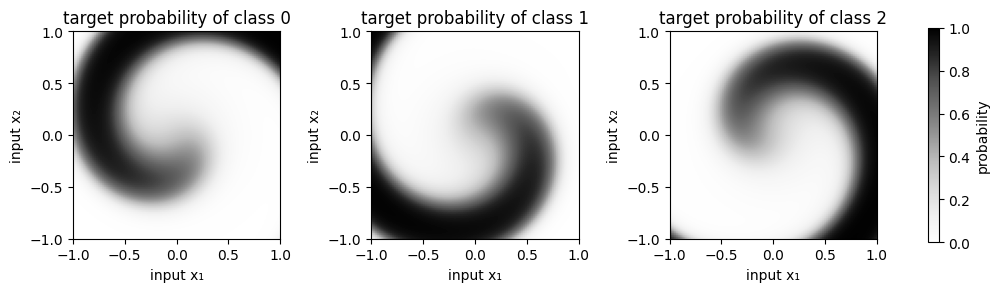

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree
from walk import random_walk

jax.config.update("jax_enable_x64", True)

def grid(n):
    z = -1 + (np.arange(n)+.5)*2/n
    xx, yy = np.meshgrid(z, z)
    return jnp.array(np.c_[xx.ravel(), yy.ravel()])

def target(x):
    phase = 4*jnp.sqrt(.1+jnp.sum(x*x, axis=1, keepdims=True))-2*jnp.pi*jnp.arange(3)/3
    return jax.nn.softmax(3*(x[:, :1]*jnp.cos(phase)-x[:, 1:]*jnp.sin(phase)), axis=1)

# A dense training grid and a separate, finer evaluation grid.
train_x, test_x = grid(41), grid(100)
train_p, test_p = target(train_x), np.array(target(test_x))
rng = np.random.default_rng(0)
layers = [(jnp.array(rng.normal(size=(a,b))*np.sqrt(2/(a+b))),jnp.zeros(b))
          for a,b in [(2,32),(32,32),(32,3)]]
theta, unpack = ravel_pytree(layers)

def logits(theta, x):
    (w1,b1),(w2,b2),(w3,b3) = unpack(theta)
    return jnp.tanh(jnp.tanh(x@w1+b1)@w2+b2)@w3+b3

def probabilities(theta, x):
    return jax.nn.softmax(logits(theta,x), axis=-1)

def batch_loss(theta, x, p):
    return -jnp.mean(jnp.sum(p*jax.nn.log_softmax(logits(theta,x)),axis=1))

loss = jax.jit(lambda theta: batch_loss(theta,train_x,train_p))
entropy = float(-jnp.mean(jnp.sum(train_p*jnp.log(train_p),axis=1)))

fig, ax = plt.subplots(1,3,figsize=(10,3),layout="constrained")
for k in range(3):
    image = ax[k].imshow(test_p[:,k].reshape(100,100),origin="lower",extent=(-1,1,-1,1),
                         cmap="Greys",vmin=0,vmax=1)
    ax[k].set(title=f"target probability of class {k}",xlabel="input x₁",ylabel="input x₂")
fig.colorbar(image,ax=ax,shrink=.8,label="probability")
plt.show()

## SGD establishes the reference

Each update uses a randomly sampled minibatch. Momentum averages recent stochastic gradients. The full training curve shows the approach to a plateau, and its enlarged tail shows the remaining drift.

The gap above $H(p)$ measures approximation error. Once that gap changes slowly, the fitted weights provide a reference for exploring similarly fitted functions.

Reference CE: 0.52389955; excess above entropy: 0.00026870
CE change over final 10,000 SGD updates: 8.5e-06


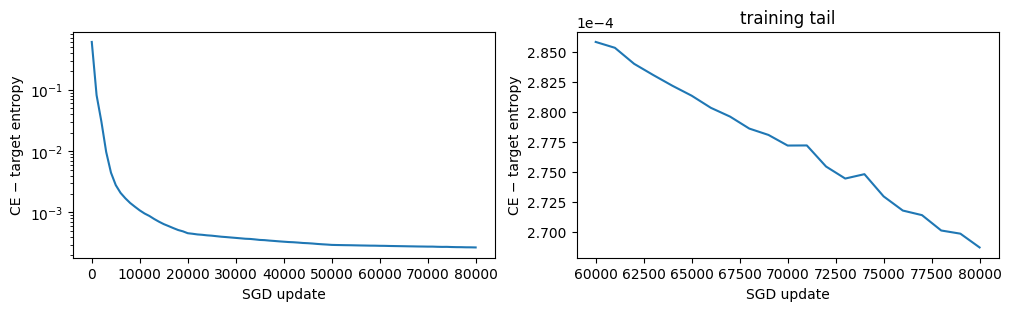

In [2]:
@jax.jit
def sgd_chunk(theta, velocity, key, updates):
    def update(state, index):
        theta, velocity, key = state
        key, draw = jax.random.split(key)
        ids = jax.random.randint(draw,(256,),0,len(train_x))
        gradient = jax.grad(batch_loss)(theta,train_x[ids],train_p[ids])
        velocity = .9*velocity+gradient
        rate = jnp.where(index<20000,.03,jnp.where(index<50000,.01,.003))
        return (theta-rate*velocity,velocity,key), None
    return jax.lax.scan(update,(theta,velocity,key),updates)[0]

# Actual minibatch SGD with momentum; no Adam or checkpoint initialization.
# Freeze training schedule before looking at exploration properties.
velocity, key = jnp.zeros_like(theta), jax.random.PRNGKey(10)
history = [float(loss(theta))]
for start in range(0,80000,1000):
    theta,velocity,key = sgd_chunk(theta,velocity,key,jnp.arange(start,start+1000))
    history.append(float(loss(theta)))
theta0 = theta
L0 = float(loss(theta0))
history = np.array(history)
print(f"Reference CE: {L0:.8f}; excess above entropy: {L0-entropy:.8f}")
print(f"CE change over final 10,000 SGD updates: {history[-11]-history[-1]:.3g}")

fig,ax = plt.subplots(1,2,figsize=(10,3),layout="constrained")
updates = np.arange(len(history))*1000
ax[0].semilogy(updates,history-entropy)
ax[0].set(xlabel="SGD update",ylabel="CE − target entropy")
ax[1].plot(updates[-21:],history[-21:]-entropy)
ax[1].set(xlabel="SGD update",ylabel="CE − target entropy",title="training tail")
ax[1].ticklabel_format(axis="y",style="sci",scilimits=(0,0),useOffset=False)
plt.show()

## Follow random directions within a loss band

Let $\theta_0$ be the trained weights and $L_0=L(\theta_0)$. The admissible neighborhood is
$$
\mathcal N_\varepsilon=\{\theta:|L(\theta)-L_0|\le\varepsilon\}.
$$
The band uses total cross-entropy. In the training curve, subtracting $H(p)$ makes the remaining approximation error visible.

Draw a random weight direction $r$. With $g=\nabla_\theta L$, remove its component normal to the local loss level:
$$
v=r-\frac{r^\top g}{g^\top g}g,\qquad
\widetilde\theta=\theta+h\,\frac{v}{\|v\|}.
$$
For nonzero $g$, the linear term $g^\top v$ vanishes. At a stationary point every direction has zero first-order loss change. Curvature determines how the loss changes over a finite step.

The walk retains some directional persistence between random draws. If a proposal leaves the band, bounded corrections along the loss gradient try to return it. Evaluating the full training loss determines acceptance at each proposed state.

The implementation is in [walk.py](walk.py). Its random directions are defined in the current weight coordinates, so the parameterization and direction distribution determine which parts of the neighborhood are visited.

Accepted proposals per path: [597 578 600 597 600 599]
Largest recorded relative loss change: 0.01999966302907641


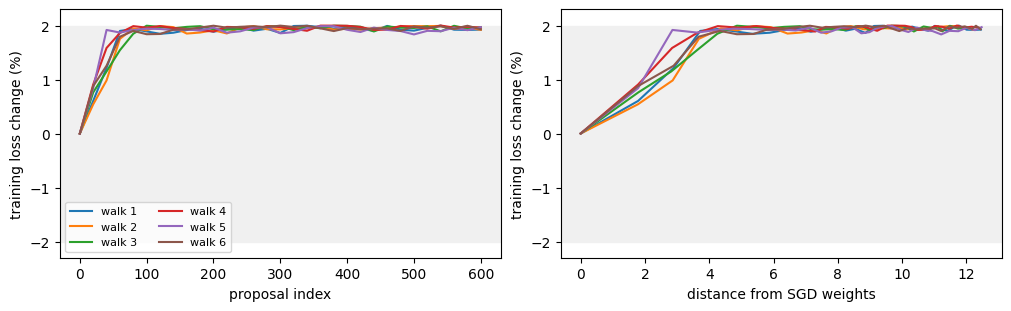

In [3]:
# All settings are fixed before evaluating any behavioral or algebraic property.
# Keep all six streams and their fixed endpoints, not a best-looking subset.
paths, path_losses, acceptance = [], [], []
for seed in range(6):
    weights, values, decisions = random_walk(loss,theta0,seed=100+seed,
        step_size=.12,steps=600,relative_band=.02,persistence=.9,record_every=20)
    paths.append(weights)
    path_losses.append(values)
    acceptance.append(decisions)
paths, path_losses, acceptance = np.array(paths),np.array(path_losses),np.array(acceptance)
models = jnp.array(np.concatenate([np.array(theta0)[None],paths[:,-1]],axis=0))
names = ["SGD"]+[f"walk {i+1}" for i in range(6)]
print("Accepted proposals per path:",acceptance.sum(1))
print("Largest recorded relative loss change:",np.max(abs(path_losses/L0-1)))

fig,ax = plt.subplots(1,2,figsize=(10,3),layout="constrained")
for i,(weights,values) in enumerate(zip(paths,path_losses)):
    ax[0].plot(np.arange(len(values))*20,100*(values/L0-1),label=f"walk {i+1}")
    ax[1].plot(np.linalg.norm(weights-np.array(theta0),axis=1),100*(values/L0-1))
for axis in ax:
    axis.axhspan(-2,2,color="0.94")
    axis.set(ylabel="training loss change (%)",ylim=(-2.3,2.3))
ax[0].set_xlabel("proposal index")
ax[1].set_xlabel("distance from SGD weights")
ax[0].legend(ncol=2,fontsize=8)
plt.show()

## What part of the loss landscape was reached?

Take the displacements from the reference to the first two fixed endpoints, $d_1=\theta_1-\theta_0$ and $d_2=\theta_2-\theta_0$. Their affine plane has the loss section
$$
S(a,b)=L(\theta_0+a d_1+b d_2).
$$
The coordinates $(0,0)$, $(1,0)$ and $(0,1)$ are actual networks already encountered. Every other colored point is a newly evaluated network in this plane.

The walks move through the full weight space; the section marks their endpoints in this plane. The second panel compares straight interpolation to each endpoint with the losses recorded along the walks.

The color scale is linear near the admissible band and logarithmic farther away, so both the small low-loss regions and the surrounding ridges remain visible.

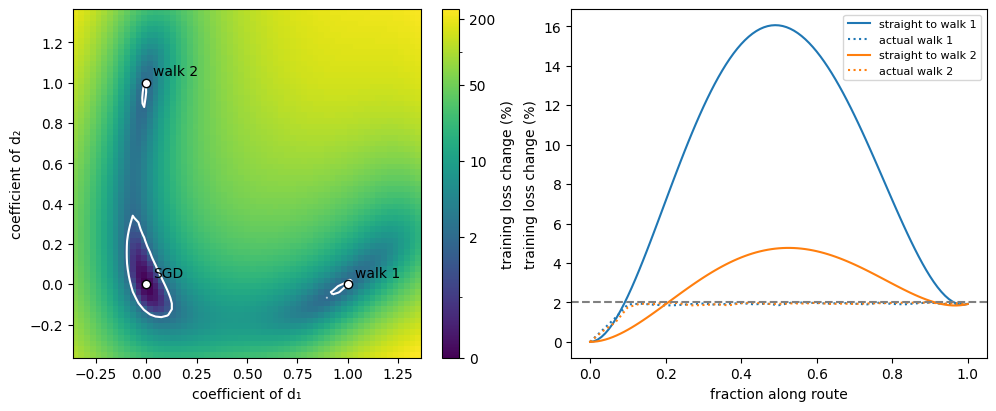

In [4]:
d1,d2 = models[1]-theta0,models[2]-theta0
coordinates = np.linspace(-.35,1.35,61)
section_row = jax.jit(jax.vmap(lambda a,b: loss(theta0+a*d1+b*d2),in_axes=(0,None)))
surface = np.array([section_row(jnp.array(coordinates),b) for b in coordinates])
t = jnp.linspace(0,1,101)
chords = np.array([jax.jit(jax.vmap(loss))(theta0+t[:,None]*(endpoint-theta0))
                   for endpoint in models[1:]])

fig,ax = plt.subplots(1,2,figsize=(10,4),layout="constrained")
change = 100*(surface/L0-1)
from matplotlib.colors import SymLogNorm
image = ax[0].pcolormesh(coordinates,coordinates,change,shading="auto",cmap="viridis",
    norm=SymLogNorm(linthresh=2,vmin=min(0.,change.min()),vmax=change.max()))
ax[0].contour(coordinates,coordinates,change,levels=[2],colors="white",linewidths=1.5)
for a,b,name in [(0,0,"SGD"),(1,0,"walk 1"),(0,1,"walk 2")]:
    ax[0].plot(a,b,"o",color="white",markeredgecolor="black")
    ax[0].annotate(name,(a,b),xytext=(5,5),textcoords="offset points")
ax[0].set(xlabel="coefficient of d₁",ylabel="coefficient of d₂",aspect="equal")
bar = fig.colorbar(image,ax=ax[0],label="training loss change (%)",ticks=[0,2,10,50,200])
bar.set_ticklabels(["0","2","10","50","200"])
for i in range(2):
    line, = ax[1].plot(t,100*(chords[i]/L0-1),label=f"straight to walk {i+1}")
    ax[1].plot(np.linspace(0,1,path_losses.shape[1]),100*(path_losses[i]/L0-1),
               ":",color=line.get_color(),label=f"actual walk {i+1}")
ax[1].axhline(2,color="0.5",linestyle="--")
ax[1].set(xlabel="fraction along route",ylabel="training loss change (%)")
ax[1].legend(fontsize=8)
plt.show()

## Compare the represented functions

Permuting the neurons of a hidden layer and the corresponding inputs of the next layer preserves the network's computation. This gives a concrete example of distinct weight vectors representing the same function.

Compare the permutation with the randomly reached endpoints. Function distance is measured on probability vectors,
$$
d(f_i,f_j)=\sqrt{\mathbb E_x\|q_i(x)-q_j(x)\|_2^2}.
$$
Label disagreement measures how often the largest probability belongs to a different class.

Permutation control: maximum probability change 1.609823385706477e-15


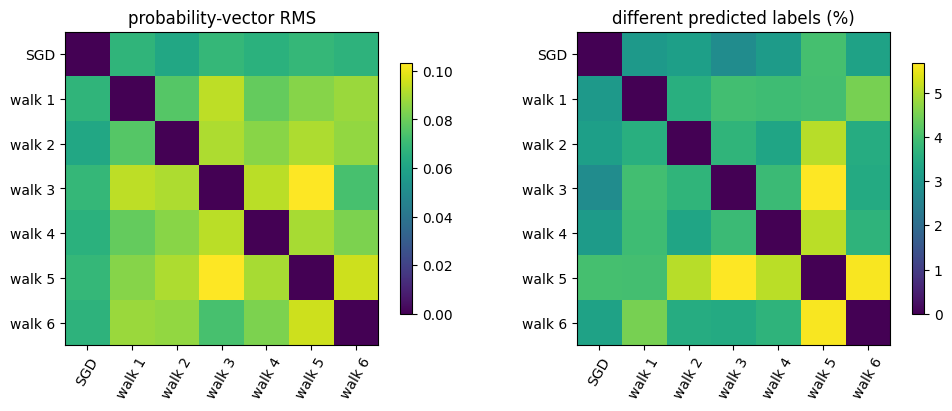

RMS from SGD: [0.06753078 0.06187081 0.06890402 0.06582429 0.06866579 0.06659152]
Label disagreement from SGD: [0.0306 0.0321 0.0276 0.0311 0.0399 0.0327]


In [5]:
prediction = jax.jit(probabilities)
q = np.array([prediction(theta,test_x) for theta in models])
(w1,b1),(w2,b2),(w3,b3) = unpack(theta0)
permutation = np.random.default_rng(31).permutation(w1.shape[1])
permuted,_ = ravel_pytree([(w1[:,permutation],b1[permutation]),
                          (w2[permutation,:],b2),(w3,b3)])
print("Permutation control: maximum probability change",
      float(jnp.max(abs(prediction(permuted,test_x)-prediction(theta0,test_x)))))
rms = np.sqrt(np.mean(np.sum((q[:,None]-q[None,:])**2,axis=-1),axis=-1))
labels = q.argmax(-1)
disagreement = np.mean(labels[:,None]!=labels[None,:],axis=-1)

fig,ax = plt.subplots(1,2,figsize=(10,4),layout="constrained")
for axis,array,title in zip(ax,[rms,100*disagreement],
                            ["probability-vector RMS","different predicted labels (%)"]):
    image = axis.imshow(array,cmap="viridis")
    axis.set(xticks=range(7),yticks=range(7),xticklabels=names,yticklabels=names,title=title)
    axis.tick_params(axis="x",labelrotation=60)
    fig.colorbar(image,ax=axis,shrink=.8)
plt.show()
print("RMS from SGD:",rms[0,1:])
print("Label disagreement from SGD:",disagreement[0,1:])

The permutation preserves probabilities to roundoff, while the explored endpoints produce positive function distances.

The next panels locate these changes in the input plane. Colored regions show predicted classes; black marks show where an endpoint predicts a different class from the SGD reference.

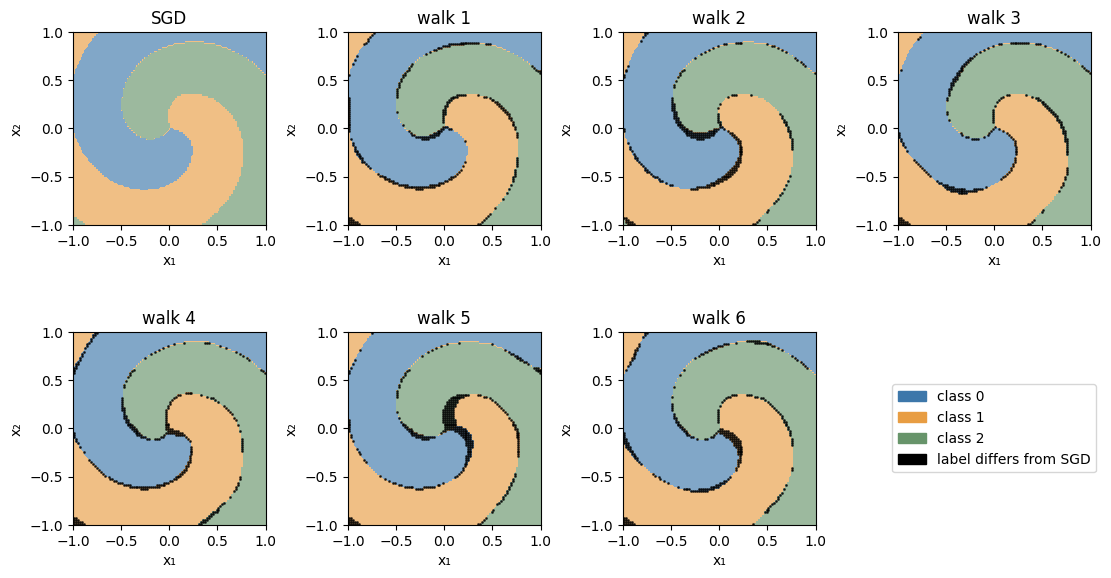

In [6]:
class_map = ListedColormap(["#3d77aa","#e89d42","#67946a"])
fig,ax = plt.subplots(2,4,figsize=(11,6),layout="constrained")
for i,axis in enumerate(ax.flat[:7]):
    axis.imshow(labels[i].reshape(100,100),origin="lower",extent=(-1,1,-1,1),
                cmap=class_map,vmin=0,vmax=2,alpha=.65)
    if i:
        different = labels[i]!=labels[0]
        xy = np.array(test_x)[different]
        axis.scatter(xy[:,0],xy[:,1],s=1,color="black",alpha=.7)
    axis.set(title=names[i],xlabel="x₁",ylabel="x₂")
ax.flat[-1].axis("off")
from matplotlib.patches import Patch
ax.flat[-1].legend(handles=[Patch(color=class_map(i),label=f"class {i}") for i in range(3)]+
    [Patch(color="black",label="label differs from SGD")],loc="center")
plt.show()

## The same average error can allocate mistakes differently

For known class probabilities, the expected confusion matrix is
$$
C_{ij}=\mathbb E_x[p_i(x)\mathbf1\{\arg\max_k q_k(x)=j\}].
$$
Its trace is expected accuracy. Normalizing a row describes where examples of that true class are sent. Comparing the matrices reveals how the error is distributed among classes at similar cross-entropy.

Calibration measures the agreement between confidence and correctness. Within each predicted-confidence bin, compare average confidence to the average target probability of the predicted class.

model       train CE  eval CE  accuracy   recall 0  recall 1  recall 2   calibration
SGD       0.523900 0.523861   0.78348    0.78966  0.77942  0.78128   0.00051
walk 1    0.533986 0.534039   0.78077    0.78313  0.78746  0.77167   0.00719
walk 2    0.533964 0.533991   0.78115    0.79099  0.78203  0.77029   0.00557
walk 3    0.534216 0.534259   0.78097    0.79922  0.76857  0.77488   0.00560
walk 4    0.534176 0.534193   0.78097    0.78210  0.78820  0.77258   0.00632
walk 5    0.534221 0.534276   0.77977    0.79421  0.76278  0.78214   0.00628
walk 6    0.534015 0.534057   0.78060    0.78780  0.77168  0.78224   0.00599


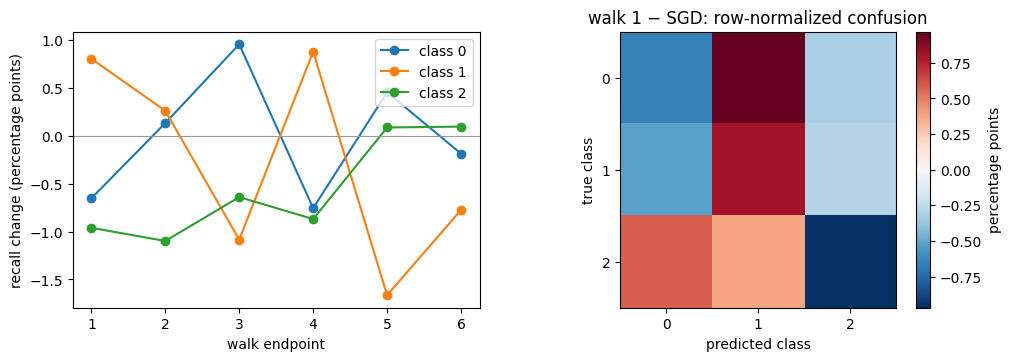

In [7]:
confusions, recalls, accuracies, calibration, test_ce = [], [], [], [], []
for probability,decision in zip(q,labels):
    confusion = test_p.T@np.eye(3)[decision]/len(test_x)
    confusions.append(confusion)
    recalls.append(np.diag(confusion)/test_p.mean(0))
    accuracies.append(np.trace(confusion))
    confidence = probability.max(1)
    correctness = test_p[np.arange(len(test_x)),decision]
    bins = np.minimum((confidence*10).astype(int),9)
    ece = sum(np.mean(bins==b)*abs(confidence[bins==b].mean()-correctness[bins==b].mean())
              for b in range(10) if np.any(bins==b))
    calibration.append(ece)
    test_ce.append(-np.mean(np.sum(test_p*np.log(probability),axis=1)))
confusions,recalls = np.array(confusions),np.array(recalls)
print("model       train CE  eval CE  accuracy   recall 0  recall 1  recall 2   calibration")
for i,name in enumerate(names):
    print(f"{name:8s} {float(loss(models[i])):9.6f} {test_ce[i]:8.6f} {accuracies[i]:9.5f}"
          f"   {recalls[i,0]:8.5f} {recalls[i,1]:8.5f} {recalls[i,2]:8.5f}   {calibration[i]:.5f}")

fig,ax = plt.subplots(1,2,figsize=(10,3.5),layout="constrained")
for k in range(3):
    ax[0].plot(range(1,7),100*(recalls[1:,k]-recalls[0,k]),"o-",label=f"class {k}")
ax[0].axhline(0,color="0.6",linewidth=.8)
ax[0].set(xlabel="walk endpoint",ylabel="recall change (percentage points)",xticks=range(1,7))
ax[0].legend()
confusion_change = 100*(confusions[1]-confusions[0])/test_p.mean(0)[:,None]
bound = np.max(abs(confusion_change))
image = ax[1].imshow(confusion_change,cmap="RdBu_r",vmin=-bound,vmax=bound)
ax[1].set(xticks=range(3),yticks=range(3),xlabel="predicted class",ylabel="true class",
          title="walk 1 − SGD: row-normalized confusion")
fig.colorbar(image,ax=ax[1],label="percentage points")
plt.show()

## Layer spectra and input sensitivity

For a layer matrix $W$, its singular values show how it stretches vectors before the nonlinearity. The stable rank
$$
r_s(W)=\frac{\sum_i\sigma_i(W)^2}{\sigma_1(W)^2}
$$
summarizes how concentrated that action is.

The input Jacobian describes the local response of the probability function:
$$
J_\theta(x)=D_xq_\theta(x).
$$
Its largest singular value gives the strongest infinitesimal probability change per unit input displacement at that point. The average squared Frobenius norm summarizes sensitivity across the square.

model       middle-layer stable rank   mean ||input Jacobian||²
SGD               3.34479                    9.14513
walk 1            5.53890                    8.32435
walk 2            5.81680                    8.70722
walk 3            5.38657                    8.18531
walk 4            6.07261                    8.38302
walk 5            6.32846                    9.13997
walk 6            5.83294                    7.88823


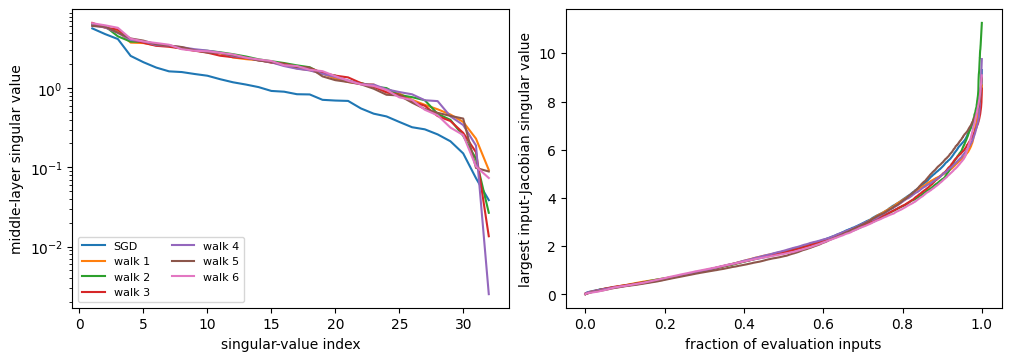

In [8]:
weight_spectra = np.array([np.linalg.svd(np.array(unpack(theta)[1][0]),compute_uv=False)
                           for theta in models])
stable_rank = np.sum(weight_spectra**2,axis=1)/weight_spectra[:,0]**2
input_jacobian = jax.jit(jax.vmap(jax.jacfwd(
    lambda theta,x: probabilities(theta,x[None])[0],argnums=1),in_axes=(None,0)))
jacobians = np.array([input_jacobian(theta,test_x) for theta in models])
jacobian_spectra = np.linalg.svd(jacobians,compute_uv=False)
sensitivity = np.mean(np.sum(jacobians**2,axis=(2,3)),axis=1)
print("model       middle-layer stable rank   mean ||input Jacobian||²")
for name,rank,energy in zip(names,stable_rank,sensitivity):
    print(f"{name:8s}       {rank:10.5f}                    {energy:.5f}")

fig,ax = plt.subplots(1,2,figsize=(10,3.5),layout="constrained")
for i,name in enumerate(names):
    ax[0].semilogy(np.arange(1,33),weight_spectra[i],label=name)
    ax[1].plot(np.linspace(0,1,len(test_x)),np.sort(jacobian_spectra[i,:,0]),label=name)
ax[0].set(xlabel="singular-value index",ylabel="middle-layer singular value")
ax[1].set(xlabel="fraction of evaluation inputs",ylabel="largest input-Jacobian singular value")
ax[0].legend(fontsize=8,ncol=2)
plt.show()

## How well do low-rank networks approximate these functions?

Truncate the middle layer's SVD to rank $r$, keep every other layer unchanged, and evaluate the resulting probability function.

The matrix approximation minimizes Frobenius error for that layer. Its effect on the full network also depends on the hidden activations, nonlinearities and downstream weights. The curves below measure that effect.

Compare two constructions: truncating each network's own middle matrix, and using the truncated SGD network as a shared approximation to every alternative. A rank-$r$ factorization of an $m\times n$ matrix uses $r(m+n)$ coefficients; storage decreases when $r(m+n)<mn$.

The triangle inequality relates the quality of the shared approximation to the distance between the functions:
$$
d(q_i,\widetilde q_{0,r})\le d(q_i,q_0)+d(q_0,\widetilde q_{0,r}).
$$
A function close to $q_0$ therefore inherits an approximation through $\widetilde q_{0,r}$. This provides a second route to a compact representation when truncating its own matrix incurs a large error.

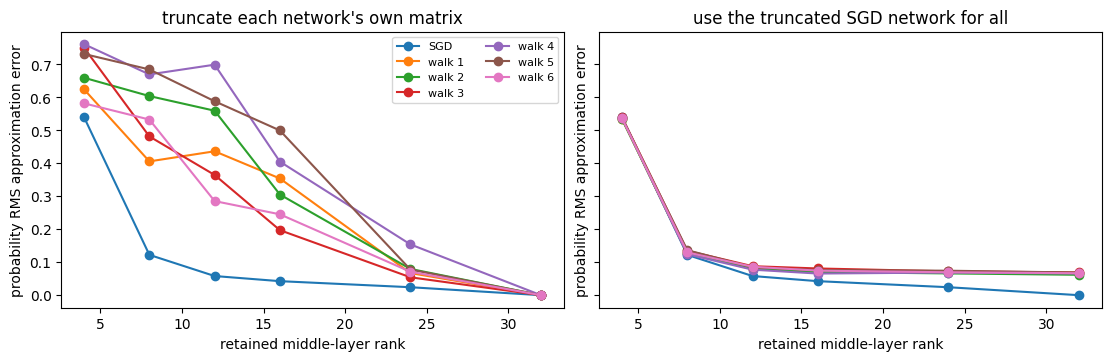

Rank-8 error: own truncation versus shared SGD approximation
SGD      0.12226  0.12226
walk 1   0.40582  0.12742
walk 2   0.60402  0.12741
walk 3   0.48152  0.13469
walk 4   0.66963  0.12414
walk 5   0.68473  0.13652
walk 6   0.53271  0.12967


In [9]:
ranks = [4,8,12,16,24,32]
approximation, reference_approximations = [], []
for i,theta in enumerate(models):
    layers = unpack(theta)
    u,s,vh = np.linalg.svd(np.array(layers[1][0]),full_matrices=False)
    errors = []
    for rank in ranks:
        reduced = list(layers)
        reduced[1] = (jnp.array((u[:,:rank]*s[:rank])@vh[:rank]),layers[1][1])
        reduced_theta,_ = ravel_pytree(reduced)
        reduced_q = np.array(prediction(reduced_theta,test_x))
        errors.append(np.sqrt(np.mean(np.sum((reduced_q-q[i])**2,axis=1))))
        if i==0:
            reference_approximations.append(reduced_q)
    approximation.append(errors)
approximation = np.array(approximation)
shared_approximation = np.array([[np.sqrt(np.mean(np.sum((reduced-q[i])**2,axis=1)))
                                  for reduced in reference_approximations] for i in range(7)])
fig,ax = plt.subplots(1,2,figsize=(11,3.5),sharey=True,layout="constrained")
for i,name in enumerate(names):
    ax[0].plot(ranks,approximation[i],"o-",label=name)
    ax[1].plot(ranks,shared_approximation[i],"o-",label=name)
ax[0].set(title="truncate each network's own matrix",xlabel="retained middle-layer rank",
          ylabel="probability RMS approximation error")
ax[1].set(title="use the truncated SGD network for all",xlabel="retained middle-layer rank",
          ylabel="probability RMS approximation error")
ax[0].legend(ncol=2,fontsize=8)
plt.show()
print("Rank-8 error: own truncation versus shared SGD approximation")
for name,own,shared in zip(names,approximation[:,1],shared_approximation[:,1]):
    print(f"{name:8s} {own:.5f}  {shared:.5f}")

## Curvature along the discovered directions

The displacements span a small subspace of weight space. Let $Q$ be an orthonormal basis for that span. The matrix
$$
H_Q=Q^\top\nabla^2 L(\theta_0)Q
$$
describes local loss curvature in this subspace. Its eigenvectors distinguish locally stiffer and flatter combinations of the discovered directions.

Comparing the quadratic approximation with the evaluated loss along a displacement shows how far this local description remains accurate.

Endpoint displacement singular values: [13.02931142 12.71149224 12.26172366 12.15955543 12.0517193  11.71806333]


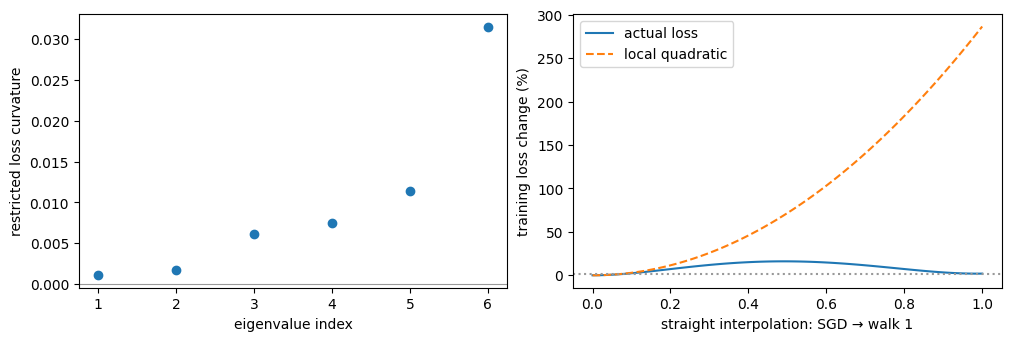

Restricted Hessian eigenvalues: [0.00105371 0.00174784 0.00615137 0.00747277 0.01139024 0.03157203]


In [10]:
displacements = np.array(models[1:]-theta0).T
print("Endpoint displacement singular values:",np.linalg.svd(displacements,compute_uv=False))
basis = jnp.array(np.linalg.qr(displacements,mode="reduced")[0])
restricted = lambda z: loss(theta0+basis@z)
gradient = np.array(jax.grad(restricted)(jnp.zeros(6)))
hessian = np.array(jax.hessian(restricted)(jnp.zeros(6)))
eigenvalues = np.linalg.eigvalsh(hessian)
z = np.array(basis.T@d1)
quadratic = L0+np.array(t)*(gradient@z)+.5*np.array(t)**2*(z@hessian@z)

fig,ax = plt.subplots(1,2,figsize=(10,3.3),layout="constrained")
ax[0].plot(np.arange(1,7),eigenvalues,"o")
ax[0].axhline(0,color="0.6",linewidth=.8)
ax[0].set(xlabel="eigenvalue index",ylabel="restricted loss curvature")
ax[1].plot(t,100*(chords[0]/L0-1),label="actual loss")
ax[1].plot(t,100*(quadratic/L0-1),"--",label="local quadratic")
ax[1].axhline(2,color="0.6",linestyle=":")
ax[1].set(xlabel="straight interpolation: SGD → walk 1",ylabel="training loss change (%)")
ax[1].legend()
plt.show()
print("Restricted Hessian eigenvalues:",eigenvalues)

## Properties of the discovered functions

All walks produced distinct probability functions. Their decision changes concentrate near class boundaries, where competing classes already have comparable probabilities. Class-wise recall and calibration vary at similar total loss.

The middle-layer spectra spread out considerably while input-Jacobian sensitivity changes less uniformly. Direct SVD truncation is less effective for the alternative weight matrices than for the SGD matrix. The truncated SGD network nevertheless approximates the alternative functions much more closely: the functions remain near a compact representation as their own matrices become harder to truncate.

Straight interpolation encounters a loss ridge, while the recorded walk states stay inside the admissible band. Along a long displacement, the quadratic approximation substantially overpredicts loss. These calculations show how the route and the scale of motion affect the geometry encountered around the trained network.